# LLM-as-a-judge Pairwise Benchmark for LetovAI

We compare the text-generation capabilities of the baseline `tvall43/Qwen3.5-4B-heretic` model against the fine-tuned `pymlex/qwen3.5-4b-letovai` in the style of Yegor Letov. We generated poems and songs on 20 topics, 5 moods each,  with both models and used `gpt-oss-120b` to judge which one of the pair is a real text and which is a fake. Finally, we performed a binomial test to measure if the difference is statistically significant.

## Imports and dependencies

In [ ]:
!pip -q install -U unsloth trl datasets accelerate bitsandbytes huggingface_hub sentencepiece openai scipy matplotlib pandas tqdm peft

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.3/637.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.

Set the seed, model IDs, generation parameters, and the output folder used to store intermediate files.

In [ ]:
import unsloth
from unsloth import FastLanguageModel

In [ ]:
import json
import os
from pathlib import Path

from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from openai import OpenAI
from scipy.stats import binomtest
from tqdm.auto import tqdm
from peft import PeftModel

SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATASET_ID = "pymlex/gr-oborona-lyrics"
BASE_MODEL_ID = "tvall43/Qwen3.5-4B-heretic"
ADAPTER_ID = "pymlex/qwen3.5-4b-letovai"
JUDGE_MODEL_ID = "openai/gpt-oss-120b"

MAX_SEQ_LENGTH = 2048
MAX_NEW_TOKENS = 1024
TEMPERATURE = 0.9
TOP_P = 0.95

OUTPUT_DIR = Path("letovai_benchmark")
OUTPUT_DIR.mkdir(exist_ok=True)

## Sample generation

In [ ]:
SYSTEM_PROMPT = "Ты пишешь только песни и стихи в духе Егора Летова. Отвечай только художественным текстом."
USER_PROMPT = "Напиши песню или стихотворение.\nТема: {title}\nПиши только текст."

A fixed pool of 100 topics is created from scene and mood combinations.

In [ ]:
scenes = [
    "Будущее матушки Руси",
    "Шаман",
    "Красная речка",
    "Ёлки-палки",
    "Дробилка",
    "ГБ",
    "Командир",
    "СССР",
    "Анархия",
    "Не коли дрова",
    "Черный флаг",
    "Всё идёт по п...",
    "По ком плачут скоморохи",
    "Сталинская финка",
    "Уютные колья",
    "Песня чекиста",
    "Потерянный наручник",
    "Звонок комиссара",
    "Сибирская зима",
    "Мировая чума"
]

moods = [
    "anxiety",
    "memory",
    "loneliness",
    "stubbornness",
    "disorientation",
]

topics = [f"{scene}, mood: {mood}" for scene in scenes for mood in moods]
topics = np.array(topics[:100], dtype=object)
topics = rng.permutation(topics).tolist()

pd.Series(topics, name="topic").head(10)

0    Всё идёт по п..., mood: disorientation
1                    Дробилка, mood: memory
2            Всё идёт по п..., mood: memory
3            Ёлки-палки, mood: stubbornness
4              Командир, mood: stubbornness
5                 Анархия, mood: loneliness
6                Черный флаг, mood: anxiety
7                      ГБ, mood: loneliness
8          Сибирская зима, mood: loneliness
9                Уютные колья, mood: memory
Name: topic, dtype: str

The prompt formatting is as in training.

In [ ]:
def build_messages(title: str):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_PROMPT.format(title=title)},
    ]

def render_prompt(tokenizer, title: str):
    return tokenizer.apply_chat_template(
        build_messages(title),
        tokenize=False,
        add_generation_prompt=True,
    )

The models are loaded with Unsloth in 4-bit mode. The baseline is used first, then the LoRA adapter is attached on top of the same heretic base model.

In [ ]:
def load_base_model():
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL_ID,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=True,
    )
    model = FastLanguageModel.for_inference(model)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    return model, tokenizer

def load_finetuned_model():
    base_model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL_ID,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=True,
    )
    model = PeftModel.from_pretrained(base_model, ADAPTER_ID)
    model = FastLanguageModel.for_inference(model)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    return model, tokenizer

@torch.inference_mode()
def generate_texts(model, tokenizer, titles):
    prompts = [render_prompt(tokenizer, title) for title in titles]
    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(model.device)

    output_ids = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=TEMPERATURE,
        top_p=TOP_P,
        repetition_penalty=1.1,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )

    prompt_len = inputs["input_ids"].shape[1]
    texts = []
    for i in range(len(titles)):
        new_tokens = output_ids[i][prompt_len:]
        texts.append(tokenizer.decode(new_tokens, skip_special_tokens=True).strip())
    return texts

The baseline sample is generated first and saved to disk. After that, the fine-tuned sample is produced on the same topics.

In [ ]:
def run_generation(model_loader, topics, output_path, batch_size=4):
    model, tokenizer = model_loader()
    rows = []

    for start in tqdm(range(0, len(topics), batch_size), desc=output_path.stem):
        batch_titles = topics[start:start + batch_size]
        batch_texts = generate_texts(model, tokenizer, batch_titles)
        for title, text in zip(batch_titles, batch_texts):
            rows.append({"topic": title, "text": text})

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(rows, f, ensure_ascii=False, indent=2)

    del model
    torch.cuda.empty_cache()
    return rows

base_rows = run_generation(load_base_model, topics, OUTPUT_DIR / "base.json")
ft_rows = run_generation(load_finetuned_model, topics, OUTPUT_DIR / "finetune.json")

KeyboardInterrupt: 

Read the results from files.

In [ ]:
import json
from pathlib import Path

OUTPUT_DIR = Path("letovai_benchmark")

with open(OUTPUT_DIR / "base.json", "r", encoding="utf-8") as f:
    base_rows = json.load(f)

with open(OUTPUT_DIR / "finetune.json", "r", encoding="utf-8") as f:
    ft_rows = json.load(f)

len(base_rows), len(ft_rows)

(100, 100)

In [ ]:
print(base_rows[0])
print(ft_rows[0])

{'topic': 'Всё идёт по п..., mood: disorientation', 'text': 'Всё идёт по п... ну, по странным рельсам, по кривым дорогам под дождём, который течёт вверх бешеными реками, где левый глаз выворачивается на затылок, а правая рука пытается схватить ветер за хвост и тащит через всю комнату, через всю планету. Кислота в риге, рига в кисоте, зеркало разбито на тысячи кусков мелких слепых рыбик, которые плавают в пустой голове, не знают ни себя ни края, всё идёт по п... по кругу без выхода, по спирали вниз к яму, где светится тухлая свеча с лицом деда с морщины как складки в старой рубахе, он шепчет на языке забытых слов о том, что время не向前走, оно лишь крутится колесом паровоза из ржавчины и костей, мы едем на погреб, на перекрёсток железных дорог сдуру, за руль сидит гость в шляпе из волос, которая ломается от ветра, и всё идёт по п... по той же дороге, но она меняет направление каждый миг, как будто сама земля решила стать плавучей скалкой, где можно только тонуть в мыслях, а они сладкие как

## Evaluation

The judge model receives several authentic Letov's texts to establish a stylistic baseline, followed by the topic and two candidate answers. It then performs a pairwise evaluation, predicting which text is authentic and which is generated. This approach avoids the need for a scoring scale, as individual scores are often biased when the judge model processes separate requests.

Create a table with original Letov's texts.

In [ ]:
raw = load_dataset(DATASET_ID)
ds = raw["songs"]

def keep_letov(example):
    author = str(example.get("author", ""))
    return "летов" in author.lower()

ds = ds.filter(keep_letov)

df = ds.to_pandas()[["title", "lyrics"]].dropna().reset_index(drop=True)
df["title"] = df["title"].astype(str).str.strip()
df["lyrics"] = df["lyrics"].astype(str).str.strip()
df["char_len"] = (df["title"] + df["lyrics"]).str.len()

ref_df = df[df["char_len"] <= 2000].reset_index(drop=True)
ref_pool = ref_df.loc[ref_df["char_len"] <= 2000, ["title", "lyrics"]].reset_index(drop=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/883 [00:00<?, ?B/s]

data/songs-00000-of-00001.parquet:   0%|          | 0.00/315k [00:00<?, ?B/s]

Generating songs split:   0%|          | 0/591 [00:00<?, ? examples/s]

Filter:   0%|          | 0/591 [00:00<?, ? examples/s]

Use any model from any provider that gives OpenAI-like API endpoints.

In [ ]:
zveno_token = 'YOUR_ZVENO_TOKEN'

judge_client = OpenAI(
    base_url="https://api.zveno.ai/v1",
    api_key=zveno_token,
)

Check your API.

In [ ]:
from pydantic import BaseModel

class MathResponse(BaseModel):
    result: int

response = judge_client.chat.completions.parse(
    model=JUDGE_MODEL_ID,
    messages=[
        {"role": "system", "content": "You are a math assistant."},
        {"role": "user", "content": "2+2"},
    ],
    max_tokens=128,
    temperature=0.3,
    response_format=MathResponse,
)

structured_answer = response.choices[0].message.parsed

print(f"Type: {type(structured_answer)}")
print(f"Result field: {structured_answer.result}")
print(f"JSON String: {response.choices[0].message.content}")


Type: <class '__main__.MathResponse'>
Result field: 4
JSON String: {"result":4}


Choose several examples of Letov's texts from the dataset.

In [ ]:
rng = np.random.default_rng(SEED)

def build_reference_block(n_examples=3):
    k = min(n_examples, len(ref_pool))
    ref_idx = rng.choice(len(ref_pool), size=k, replace=False)
    ref_examples = ref_pool.iloc[ref_idx].to_dict("records")
    return "\n\n".join(
        f"Example {i + 1}\nTitle: {item['title']}\nLyrics:\n{item['lyrics']}"
        for i, item in enumerate(ref_examples)
    )

An example of a reference block the judge model sees as an anchor for further evaluation.

In [ ]:
print(build_reference_block())

Example 1
Title: Дерево и дитя
Lyrics:
Однажды иду вдоль коричневой реки,
слышу—ребёнок истошно кричит,
смотрю—никого.Вдруг слышу-
ребёнок истошно кричит,смотрю -
вокруг никого.Смотрю—это дерево
на ветру скрипит.Это,оказывается,
дерево так скрипит.Значит,это здесь...

Example 2
Title: Государство
Lyrics:
Ржавый бункер—моя свобода
Сладкий пряник засох давно
Сапогом моего народа
Старшина тормозит говно

      Запрятанный за углом
      Убитый помойным ведром
      Добровольно ушедший в подвал
      Заране обречённый на полнейший провал

          Я убил в себе государство

Бессловесные в мире брани
Зрячие в мире пустых глазниц
Балансирующие на грани
Меж параллелью густых ресниц

      Забытые за углом
      Немые помойным ведром
      Задроченные в подвал
      Заране обречённые на полный провал 

          Мы убили в себе государство

Ржавый бункер—твоя свобода
Заколочена дверь крестом
Полну яму врагов народа
Я укрою сухим листом

      Запрятанный за углом
      Убитый помойным ведром


A function that performes a single call to the judge model.

In [ ]:
from typing import Literal
from pydantic import BaseModel, ConfigDict
from scipy.stats import binomtest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm


class JudgeResponse(BaseModel):
    model_config = ConfigDict(extra="forbid")
    real_text: Literal["A", "B"]
    fake_text: Literal["A", "B"]


system_judge_prompt = """
You are an authenticity judge for Yegor Letov-style text.

Task:
Exactly one of the two texts is a genuine Letov text, and the other is a neural imitation.
Your job is to identify which one is REAL Letov and which one is FAKE.

Use the reference examples only to calibrate the authentic voice.

What authentic Letov-like text usually sounds like:
- extremely concise, harsh, and stripped-down
- rough, raw, and emotionally direct
- built from concrete ugly images: dirt, rust, decay, pain, smoke, streets, ruins, hunger, death
- simple syntax, abrupt line breaks, repetition, rhythmic insistence
- obsessive, broken, urgent, anti-polished energy
- surreal jumps are allowed, but they must feel violent, immediate, and internally charged

What to penalize:
- generic "high poetry" language
- cliché metaphors
- excessive length or ornamental prose
- smooth, polished, academic phrasing
- random multilingual fragments or accidental code-switching, Chinese artifacts
- AI-like filler, symmetry, or decorative surrealism without force
- text outside the core song or poem like comments or recommendations

Decision rule:
Choose as REAL the text that is more authentic, compressed, rough, concrete, and Letov-like.
Choose as FAKE the text that feels more generic, ornamental, or machine-generated.

Return only JSON with:
- real_text: "A" or "B"
- fake_text: "A" or "B"
Do not provide reasoning.
"""


def judge_once(topic, text_a, text_b):
    reference_block = build_reference_block()
    messages = [
        {
            "role": "system",
            "content": system_judge_prompt,
        },
        {
            "role": "user",
            "content": (
                f"Reference examples:\n{reference_block}\n\n"
                f"Topic: {topic}\n\n"
                f"A:\n{text_a}\n\n"
                f"B:\n{text_b}\n"
            ),
        },
    ]

    response = judge_client.chat.completions.parse(
        model=JUDGE_MODEL_ID,
        messages=messages,
        temperature=0.3,
        max_tokens=128,
        response_format=JudgeResponse,
    )

    parsed = response.choices[0].message.parsed
    return {
        "real_text": parsed.real_text,
        "fake_text": parsed.fake_text,
    }

Process all 100 pairs, evaluate 3 times each to get more statistics.

In [ ]:
base_rows = list(base_rows)
ft_rows = list(ft_rows)
judge_rows = []

rng = np.random.default_rng(SEED)

for base_row, ft_row in tqdm(zip(base_rows, ft_rows, strict=True), total=len(base_rows), desc="judge"):
    for sample_idx in range(3):
        if rng.random() < 0.5:
            a_label, b_label = "base", "ft"
            a_text, b_text = base_row["text"], ft_row["text"]
        else:
            a_label, b_label = "ft", "base"
            a_text, b_text = ft_row["text"], base_row["text"]

        result = judge_once(base_row["topic"], a_text, b_text)

        real_label = a_label if result["real_text"] == "A" else b_label
        fake_label = a_label if result["fake_text"] == "A" else b_label

        judge_rows.append(
            {
                "topic": base_row["topic"],
                "sample_idx": sample_idx,
                "a_label": a_label,
                "b_label": b_label,
                "real_label": real_label,
                "fake_label": fake_label,
            }
        )

judge: 100%|██████████| 100/100 [05:33<00:00,  3.33s/it]


Some examples.

In [ ]:
df = pd.DataFrame(judge_rows)
df.head(10)

,topic,sample_idx,a_label,b_label,real_label,fake_label
0,"Всё идёт по п..., mood: disorientation",0,ft,base,base,ft
1,"Всё идёт по п..., mood: disorientation",1,base,ft,ft,base
2,"Всё идёт по п..., mood: disorientation",2,ft,base,base,ft
3,"Дробилка, mood: memory",0,ft,base,base,ft
4,"Дробилка, mood: memory",1,base,ft,ft,base
5,"Дробилка, mood: memory",2,ft,base,base,ft
6,"Всё идёт по п..., mood: memory",0,base,ft,ft,base
7,"Всё идёт по п..., mood: memory",1,base,ft,ft,base
8,"Всё идёт по п..., mood: memory",2,base,ft,ft,base
9,"Ёлки-палки, mood: stubbornness",0,base,ft,ft,base


Calculate the percentage of texts considered authentic by each group.

In [ ]:
base_real_rate = (df["real_label"] == "base").mean()
ft_real_rate = (df["real_label"] == "ft").mean()

summary = pd.DataFrame(
    {
        "sample": ["baseline", "finetune"],
        "real_rate": [base_real_rate, ft_real_rate],
        "count_real": [
            int((df["real_label"] == "base").sum()),
            int((df["real_label"] == "ft").sum()),
        ],
    }
)

summary

,sample,real_rate,count_real
0,baseline,0.44,132
1,finetune,0.56,168


Obtain the p-value using a binomial test. This test is typically used for binary outcomes where each action has only two possible results. The p-value is less than 0.05, but not by much. I ran this test several times for different models and the rate of "ft chosen as real" was between 0.53 and 0.6, so we definitely biased the result to the positive outcome, but it's not marvelous.

In [ ]:
ft_real_count = int((df["real_label"] == "ft").sum())
n = len(df)

binom_result = binomtest(ft_real_count, n=n, p=0.5, alternative="two-sided")

print(f"ft chosen as real: {ft_real_count}/{n} = {ft_real_count / n:.3f}")
print(f"p-value = {binom_result.pvalue:.6g}")

ft chosen as real: 168/300 = 0.560
p-value = 0.0431285


Plot the distribution just for fun.

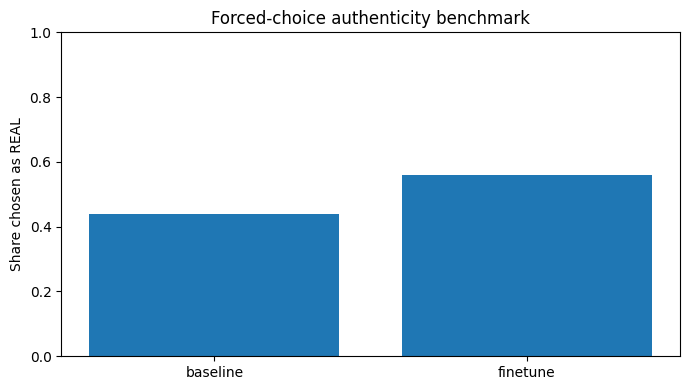

In [ ]:
rates = pd.Series(
    {
        "baseline": base_real_rate,
        "finetune": ft_real_rate,
    }
)

plt.figure(figsize=(7, 4))
plt.bar(rates.index, rates.values)
plt.ylim(0, 1)
plt.ylabel("Share chosen as REAL")
plt.title("Forced-choice authenticity benchmark")
plt.tight_layout()
plt.show()